# 3. Install the Hugging Face Transformers library and run a pre-trained transformer model on a simple task (e.g., text classification).  

In [ ]:
!pip install transformers datasets pandas matplotlib seaborn --quiet


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
from datasets import load_dataset


In [ ]:
dataset = load_dataset("amazon_polarity")
df=pd.DataFrame(dataset['train'])
df=df.sample(500,random_state=42)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

,label,title,content
2079998,0,Expensive Junk,This product consists of a piece of thin flexi...
1443106,0,Toast too dark,"Even on the lowest setting, the toast is too d..."
3463669,1,Excellent imagery...dumbed down story,I enjoyed this disc. The video is stunning. I ...
2914699,0,Are we pretending everyone is married?,The authors pretend that parents neither die n...
1603231,0,Not worth your time,"Might as well just use a knife, this product h..."


In [ ]:
df['review']=df['title']+" "+df['content']

df=df[['review','label']]

df.head()

,review,label
2079998,Expensive Junk This product consists of a piec...,0
1443106,"Toast too dark Even on the lowest setting, the...",0
3463669,Excellent imagery...dumbed down story I enjoye...,1
2914699,Are we pretending everyone is married? The aut...,0
1603231,Not worth your time Might as well just use a k...,0


In [ ]:
classifier = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0  # Use GPU if available
)


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
sample_review = df['review'].iloc[0]

result = classifier(sample_review)

print("Review:", sample_review[:200])
print("Prediction:", result)


Review: Expensive Junk This product consists of a piece of thin flexible insulating material, adhesive backed velcro and white electrical tape.Problems:1. Instructions are three pictures with little more info
Prediction: [{'label': '1 star', 'score': 0.9323087334632874}]


In [ ]:
def get_sentiment(review):
    result = classifier(review[:512])[0]  # limit length
    return result['label'], result['score']

results = df['review'].apply(get_sentiment)

df['predicted_sentiment'] = results.apply(lambda x: x[0])
df['confidence'] = results.apply(lambda x: x[1])

df.head()


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,review,label,predicted_sentiment,confidence
2079998,Expensive Junk This product consists of a piec...,0,1 star,0.934274
1443106,"Toast too dark Even on the lowest setting, the...",0,2 stars,0.544465
3463669,Excellent imagery...dumbed down story I enjoye...,1,3 stars,0.570597
2914699,Are we pretending everyone is married? The aut...,0,1 star,0.502895
1603231,Not worth your time Might as well just use a k...,0,1 star,0.858363


In [ ]:
def stars_to_numeric(star_label):
    return int(star_label.split()[0])

df['sentiment_score'] = df['predicted_sentiment'].apply(stars_to_numeric)

df.head()


,review,label,predicted_sentiment,confidence,sentiment_score
2079998,Expensive Junk This product consists of a piec...,0,1 star,0.934274,1
1443106,"Toast too dark Even on the lowest setting, the...",0,2 stars,0.544465,2
3463669,Excellent imagery...dumbed down story I enjoye...,1,3 stars,0.570597,3
2914699,Are we pretending everyone is married? The aut...,0,1 star,0.502895,1
1603231,Not worth your time Might as well just use a k...,0,1 star,0.858363,1


In [ ]:
average_sentiment = df['sentiment_score'].mean()

positive_percent = (df['sentiment_score'] >= 4).mean() * 100
negative_percent = (df['sentiment_score'] <= 2).mean() * 100
neutral_percent = ((df['sentiment_score'] == 3).mean()) * 100

print("Average Sentiment Score:", average_sentiment)
print("Positive Reviews %:", positive_percent)
print("Neutral Reviews %:", neutral_percent)
print("Negative Reviews %:", negative_percent)


Average Sentiment Score: 2.962
Positive Reviews %: 44.6
Neutral Reviews %: 8.6
Negative Reviews %: 46.800000000000004


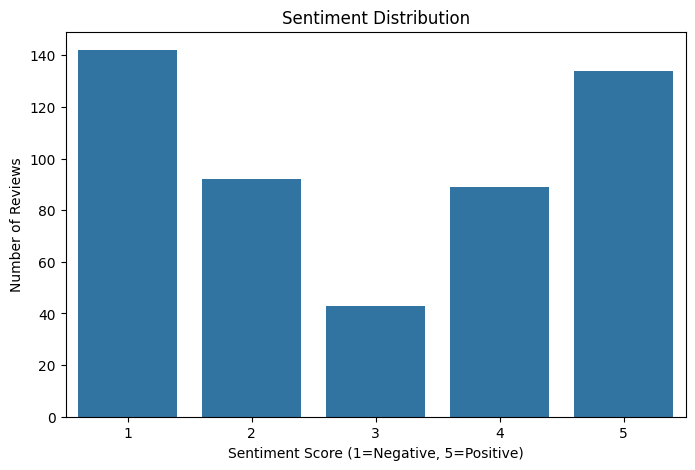

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['sentiment_score'])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Score (1=Negative, 5=Positive)")
plt.ylabel("Number of Reviews")

plt.show()


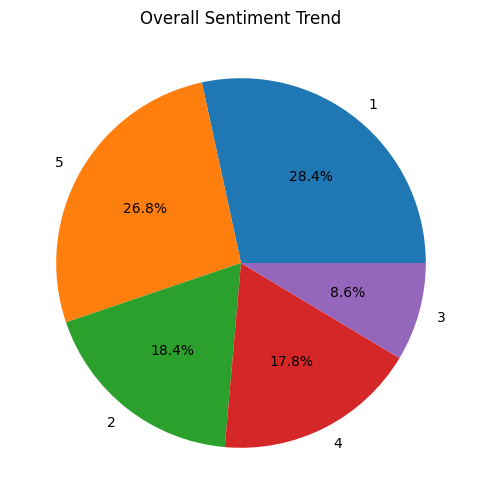

In [ ]:
sentiment_counts = df['sentiment_score'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Overall Sentiment Trend")

plt.show()


In [ ]:
print("Most Positive Review:")
print(df.sort_values("sentiment_score", ascending=False)['review'].iloc[0])

print("\nMost Negative Review:")
print(df.sort_values("sentiment_score")['review'].iloc[0])


Most Positive Review:
Great Guide I used this guide several times while in amsterdam recently. It was a great book to use to familiarize myself with the city and get an idea of what I was and wasnt interested in doing.The information is straight forward and useful. I recommend this book.

Most Negative Review:
Expensive Junk This product consists of a piece of thin flexible insulating material, adhesive backed velcro and white electrical tape.Problems:1. Instructions are three pictures with little more information.2. Velcro was all crumpled as received and was stronger than the adhesive. When i tried to disengage the velcro both pieces came off and the paint from the ceiling.3. White electrical tape was horrible... cheap, narrow and it fell off in less than 1 hour.4. The price is a ripoff.I am building my own which is easier to use, cheaper, more attractive, and higher r-value. I am surprised Amazon even lists this junk.


In [ ]:
print("PRODUCT SENTIMENT ANALYSIS SUMMARY")
print("-----------------------------------")

print(f"Average Sentiment Score: {average_sentiment:.2f}/5")

if average_sentiment >= 4:
    print("Overall sentiment is VERY POSITIVE")
elif average_sentiment >= 3:
    print("Overall sentiment is POSITIVE")
elif average_sentiment >= 2:
    print("Overall sentiment is NEUTRAL")
else:
    print("Overall sentiment is NEGATIVE")

print(f"\nPositive Reviews: {positive_percent:.2f}%")
print(f"Neutral Reviews: {neutral_percent:.2f}%")
print(f"Negative Reviews: {negative_percent:.2f}%")


PRODUCT SENTIMENT ANALYSIS SUMMARY
-----------------------------------
Average Sentiment Score: 2.96/5
Overall sentiment is NEUTRAL

Positive Reviews: 44.60%
Neutral Reviews: 8.60%
Negative Reviews: 46.80%


In [ ]:
while True:
    review = input("\nEnter a business review (or type 'exit'): ")

    if review.lower() == "exit":
        break

    result = classifier(review)[0]

    print("Sentiment:", result['label'])
    print("Confidence:", result['score'])
